
---

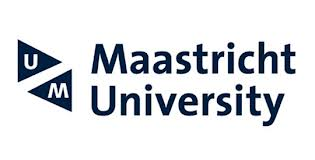

# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing - Tutorial Transformers - Decoder-only Models

⏱️ **Estimated time:** ~35 min reading/demos + ~45 min exercises (≈80 min total)

By Jan Scholtes

---

Version 2026-2027

---

Welcome to the tutorial on Decoder Models and GPT. In this notebook you will learn about decoder-only Transformer models (the GPT family), explore different text generation strategies, experiment with prompting techniques, and understand the key concepts behind Retrieval Augmented Generation (RAG).

For this notebook we would need our GPU accelerator.

## Learning Goals

After completing this tutorial, you will be able to:

- **Understand** decoder-only Transformer models (GPT family) and how they differ from encoder and encoder-decoder architectures.
- **Explain** the autoregressive generation process and why context length matters.
- **Apply** different text generation (decoding) strategies: greedy, beam search, random sampling, temperature, top-k, and nucleus sampling.
- **Compare** the quality and characteristics of text produced by different decoding strategies.
- **Understand** prompting techniques: zero-shot, few-shot, chain of thought, self-consistency and tree of thoughts, and know when they help.
- **Explain** what a reasoning model is and how it differs from a prompted model.
- **Explain** what Retrieval Augmented Generation (RAG) is and why it helps reduce hallucinations.
- **Discuss** risks, limitations, and ethical considerations of generative language models.

## Decoder-Only Transformer Architecture

In Tutorial 07 (Transformers) and Tutorial 08 (Encoder Models), we explored the full Transformer architecture and encoder-only models like BERT. Now we turn to **decoder-only** models -- the architecture behind the GPT family.

### Key Properties of Decoder-Only Models

- GPT models use **only the decoder** part of the Transformer architecture.
- They are trained with a **left-to-right language modeling objective**: predict the next token given all previous tokens.
- Self-attention is **causal** (masked): each token can only attend to tokens that came before it, not future tokens.
- Generation is **autoregressive**: the model generates one token at a time, feeding each generated token back as input.
- Best suited for **text generation** tasks based on zero/few-shot learning (the "prompt").

### Decoder vs. Encoder vs. Encoder-Decoder

| Architecture | Example Models | Self-Attention | Best For |
|---|---|---|---|
| **Encoder-only** | BERT, RoBERTa | Bidirectional (sees full context) | Classification, NER, Q&A extraction |
| **Decoder-only** | GPT-2/3/4/5 | Causal (left-to-right only) | Text generation, completion, chat |
| **Encoder-Decoder** | T5, BART | Encoder: bidirectional; Decoder: causal | Translation, summarization |

### What happened to the encoder's self-attention?

In decoder-only models, there is no separate encoder. The prompt itself serves as the "context" that the decoder attends to through **causal self-attention**. Every token in the prompt directly expands the self-attention graph, which is why context length matters so much for GPT models.

## Context Length in GPT Models

Context length is critical for decoder-only models because **every token attends to the entire raw history**. This makes cost and memory scale as $O(n^2)$ throughout generation.

### Computational Complexity

**Training**: Each token attends to all previous ones. Cost per layer is approximately $O(n^2 d)$ (attention) + $O(n d^2)$ (FFN), where $n$ is the sequence length and $d$ is the embedding dimension.

**Inference** (autoregressive): To generate $m$ new tokens given a prompt of length $p$:
- First token: attends to $p$ tokens (cost $O(p^2 d)$)
- Each new token $t$ attends to $p + t$ tokens
- Total: approximately $O(m(p + m)d)$

Since you generate one token at a time, you re-run attention over the **entire growing context**. For very long contexts (128k+ tokens in GPT-4), each extra token becomes increasingly expensive.

### Context Sizes Over Time

| Model | Context Window |
|---|---|
| Original Transformer (2017) | 512 tokens |
| GPT-2 (2019) | 1,024 tokens |
| GPT-3 (2020) | 2,048 tokens |
| GPT-4 (2023) | 8k / 128k tokens |
| GPT-5 (2025) | ~400k tokens |

> **Why does this matter?** Encoder-decoder models compress the input once, so decoding does not get exponentially more expensive with long source sequences. GPT-style models must re-attend to everything, making context window size a key design constraint.

## A Brief History of GPT Models

| Model | Year | Key contribution |
|---|---|---|
| **GPT-1** | 2018 | First decoder-only Transformer LM; trained on ~7,000 books; decent zero-shot Q&A/sentiment via pretraining |
| **GPT-2** | 2019 | Larger scale; strong zero/few-shot translation & summarization; initially withheld over misuse concerns |
| **GPT-3** | 2020 | 175B parameters; near-human text generation; demonstrated strong few-shot learning |
| **ChatGPT** | Nov 2022 | GPT-3.5 + **RLHF** (SFT + reward model + PPO); conversational format, admits mistakes, refuses unsafe requests |
| **GPT-4** | 2023 | Multimodal (text+image); human-level on professional benchmarks; 8k/128k context |
| **o1** | Sept 2024 | First **reasoning model**: writes a long hidden chain of thought before answering, trained with reinforcement learning; accuracy rises with thinking time |
| **GPT-5** | Aug 2025 | Merges the GPT-4o line and the o-series: a router sets the reasoning effort per request; ~400k context |

**Other notable models**: Google LaMDA (2022, dialogue-focused), Meta Galactica (2022, withdrawn after 3 days due to hallucinations), Meta Llama 4 (2025, MoE, ~10M token context claimed), Google Gemini 2.5 (2025, multimodal, 1M context), Anthropic Claude 4 (2025, safety/constitutional AI focus), Mistral (2025, efficient open-weight MoE models), DeepSeek-R1 (Jan 2025, open reasoning model trained with RL on verifiable rewards; see Tutorial 11).

Naming trap: GPT-4o mini (July 2024) is an *omni* model; o3-mini (Jan 2025) is a *reasoning* model.

## Text Generation Strategies

GPT models estimate the probability $P(y|x)$ of a sequence of tokens $y = y_1, y_2, \ldots, y_i$ given an initial prompt $x = x_1, x_2, \ldots, x_k$.

This probability is computed as the product of conditional probabilities:

$$P(y|x) = \prod_{t=1}^{i} P(y_t | y_{<t}, x)$$

For each position, the model produces logits $z_{t,i}$ for every token $w_i$ in the vocabulary, and we apply softmax to get probabilities:

$$P(y_t = w_i | y_{<t}, x) = \text{softmax}(z_{t,i})$$

The key question is: **how do we select the next token from this probability distribution?** Different strategies lead to very different text quality and characteristics.

### Overview of Decoding Strategies

| Strategy | Description |
|---|---|
| **Greedy** | Always pick the highest-probability token |
| **Beam Search** | Maintain top-k candidate sequences |
| **Random Sampling** | Sample from the distribution |
| **Temperature** | Control the sharpness of the distribution |
| **Top-K Sampling** | Sample from the K most likely tokens |
| **Nucleus (Top-p)** | Sample from the smallest set of tokens whose cumulative probability exceeds p |

Let's experiment with all of these using GPT-2.

In [ ]:
# Check for GPU availability
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("⚠️ No GPU detected. Models will run on CPU (slower).")

In [ ]:
# Install requirements
import importlib, subprocess, sys
to_install = [p for p, m in [('transformers', 'transformers'), ('torch', 'torch')]
              if importlib.util.find_spec(m) is None]
if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *to_install])


In [ ]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import transformers
transformers.logging.set_verbosity_error()
from datasets import disable_progress_bar
disable_progress_bar()
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

# Load GPT-2 model and tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.eval()

# Set pad token (GPT-2 doesn't have one by default)
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

print(f"Model loaded: {model.config.n_layer} layers, {model.config.n_head} heads, {model.config.n_embd} embedding dim")
print(f"Vocabulary size: {model.config.vocab_size}")
print(f"Context window: {model.config.n_positions} tokens")

### Greedy Search

Greedy decoding simply selects the token with the highest probability at each step. It is fast but can produce repetitive and bland text, often getting stuck in loops.

$$y_t = \arg\max_{w} P(w | y_{<t}, x)$$

In [ ]:
prompt = "The future of artificial intelligence is"
input_ids = tokenizer.encode(prompt, return_tensors='pt')

# Greedy decoding (default: do_sample=False, num_beams=1)
output = model.generate(
    input_ids,
    max_new_tokens=100,
    do_sample=False,
    num_beams=1
)

print("=== Greedy Search ===")
print(tokenizer.decode(output[0], skip_special_tokens=True))

### Beam Search

Beam search maintains $k$ candidate sequences (beams) at each step and selects the sequence with the highest overall probability. It produces better results than greedy but can still be repetitive.

An **n-gram penalty** can be added to prevent repeated phrases: if generating a token would create an n-gram already seen, its probability is set to zero.

In [ ]:
# Beam search with 5 beams
output_beam = model.generate(
    input_ids,
    max_new_tokens=100,
    num_beams=5,
    no_repeat_ngram_size=2,  # Prevent repeating any 2-gram
    early_stopping=True
)

print("=== Beam Search (5 beams, no 2-gram repeat) ===")
print(tokenizer.decode(output_beam[0], skip_special_tokens=True))

### Random Sampling and Temperature

**Random sampling** draws the next token from the probability distribution rather than always picking the argmax. This introduces creativity but can also produce incoherent text.

**Temperature** ($T$) controls the sharpness of the distribution before sampling:

$$P(y_t = w_i) = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

- $T < 1$: Sharper distribution (more deterministic, less creative)
- $T = 1$: Original distribution
- $T > 1$: Flatter distribution (more random, more creative)

In [ ]:
# Compare different temperatures
for temp in [0.3, 0.7, 1.0, 1.5]:
    output_temp = model.generate(
        input_ids,
        max_new_tokens=80,
        do_sample=True,
        temperature=temp,
        top_k=0,  # Disable top-k to see pure temperature effect
    )
    print(f"=== Temperature = {temp} ===")
    print(tokenizer.decode(output_temp[0], skip_special_tokens=True))
    print()

### Top-K Sampling

Top-K sampling restricts the candidate tokens to the $K$ most probable ones. This prevents the model from selecting very unlikely tokens while still maintaining diversity.

Less probable tokens have no chance at all, reducing "weird" model behavior.

In [ ]:
# Top-K sampling
for k in [5, 20, 50]:
    output_topk = model.generate(
        input_ids,
        max_new_tokens=80,
        do_sample=True,
        top_k=k,
        temperature=0.8,
    )
    print(f"=== Top-K = {k} ===")
    print(tokenizer.decode(output_topk[0], skip_special_tokens=True))
    print()

### Nucleus (Top-p) Sampling

Nucleus sampling selects the smallest set of tokens whose cumulative probability is at least $p$. This adaptively adjusts the number of candidate tokens:
- When the model is confident, the set is small (few candidates).
- When the model is uncertain, the set is larger (more candidates).

This avoids the fixed-K problem of top-K sampling, where K might be too large (including unlikely tokens) or too small (limiting diversity) depending on context.

In [ ]:
# Nucleus sampling
for p in [0.5, 0.9, 0.95]:
    output_nucleus = model.generate(
        input_ids,
        max_new_tokens=80,
        do_sample=True,
        top_p=p,
        top_k=0,  # Disable top-k to see pure nucleus effect
        temperature=0.8,
    )
    print(f"=== Nucleus p = {p} ===")
    print(tokenizer.decode(output_nucleus[0], skip_special_tokens=True))
    print()

### Summary of Decoding Strategies

| Strategy | Pros | Cons |
|---|---|---|
| **Greedy** | Fast, deterministic | Repetitive, misses better sequences |
| **Beam Search** | Better global sequences | Still repetitive, expensive |
| **Random Sampling** | Creative, diverse | Can be incoherent |
| **Temperature** | Controls creativity | Extreme values produce garbage |
| **Top-K** | Removes unlikely tokens | Fixed K may not suit all contexts |
| **Nucleus (Top-p)** | Adaptive token set | Slightly more complex |

In practice, most production systems use a **combination**: nucleus sampling with a moderate temperature (e.g., top_p=0.9, temperature=0.7) produces the best balance of quality and diversity. ChatGPT and similar systems use variations of these strategies.

## Prompting Techniques

Since we typically cannot retrain or fine-tune large proprietary models like GPT-4, **prompting** is the primary way to control their behavior. The quality of the output depends heavily on how we formulate the input.

### Enriching a Prompt

Several strategies can improve prompt quality:
- **Context**: Provide documents, websites, or background information
- **Focus**: "Focus only on advantages/disadvantages", "Limit yourself to legal implications"
- **Impersonation**: "Write for a layman / an expert / freshmen / judges"
- **Examples**: Provide input-output pairs
- **Style and tone**: "Write formally/informally", "Use a scientific tone"
- **Structure**: "List the output", "Use subheadings and paragraphs"
- **Constraints**: "Use a maximum of 200 words", "Avoid professional jargon" 

### Zero-Shot, One-Shot, and Few-Shot Prompting

**Zero-shot**: The model is asked to perform a task without any examples -- relying entirely on its pre-trained knowledge and clear instructions.

**One-shot**: A single example is provided alongside the instruction, helping the model understand the desired format and task.

**Few-shot**: Three to five examples are provided, helping the model solve complex problems more accurately by showing multiple task variations.

The more examples provided, the more reliable the output tends to be -- but at the cost of using more of the context window.

In [ ]:
from transformers import pipeline

# Use GPT-2 for demonstration (in practice, you'd use GPT-4 or similar)
generator = pipeline('text-generation', model='gpt2', device=-1)

# Zero-shot
zero_shot_prompt = """Classify the sentiment of the following text as positive or negative.
Text: "The movie was absolutely wonderful and I loved every minute of it."
Sentiment:"""

result = generator(zero_shot_prompt, max_new_tokens=5, do_sample=False)
print("=== Zero-Shot ===")
print(result[0]['generated_text'])
print()

# Few-shot
few_shot_prompt = """Classify the sentiment of each text.

Text: "I love this product, it works perfectly!" -> Positive
Text: "Terrible experience, would not recommend." -> Negative
Text: "The food was amazing and the service was great." -> Positive
Text: "The movie was boring and too long." ->"""

result = generator(few_shot_prompt, max_new_tokens=5, do_sample=False)
print("=== Few-Shot ===")
print(result[0]['generated_text'])

### Chain of Thought (CoT) Prompting

Chain-of-thought prompting asks the model to write the intermediate steps before the answer (Wei et al. 2022). Two cheap variants:

- **Zero-shot CoT**: append "Let's think step by step" and nothing else (Kojima et al. 2022). On the MultiArith benchmark this took InstructGPT from 17.7% to 78.7%.
- **Program of Thought / PAL**: let the model write a short program as its reasoning and let the interpreter compute the answer (Chen et al. 2022; Gao et al. 2022). On GSM8K with Codex: 72% against 57% for plain CoT. A calculator is better at arithmetic than a language model.

Example (Roger has 5 tennis balls and buys 2 cans of 3):

```
Standard:   A: 11                         (often wrong on harder variants)
CoT:        Roger starts with 5. 2 cans of 3 is 6. 5 + 6 = 11. The answer is 11.
PoT:        tennis_balls = 5; bought = 2 * 3; answer = tennis_balls + bought   # interpreter prints 11
```

### Self-Consistency

Sample the chain of thought several times at a temperature above zero and take the **majority vote** over the final answers (Wang et al. 2022). Errors in individual chains differ, correct chains agree. This works whenever the answer is a short string that can be counted; it is still used in 2025 to evaluate reasoning models (reported as maj@k or cons@k).

### Tree of Thoughts (ToT)

Treat intermediate steps as nodes of a tree: generate several candidate steps, let the model rate them, search with breadth-first or depth-first search and backtrack (Yao et al. 2023). On the Game of 24, GPT-4 with CoT solved 4% of the puzzles, with ToT 74%. The cost is 10 to 100 times a single CoT call, and the weak link is the model rating its own steps.

### Skeleton of Thought (SoT): speed, not reasoning

Ask for a short skeleton (a list of points) first, then expand every point **in parallel** and concatenate (Ning et al. 2023). Up to 2.4 times faster; answer quality about the same. It looks like a reasoning method because it decomposes first, but the goal is latency.

### Four levels of prompting

| Level | Methods | Cost | Who judges a step? |
|---|---|---|---|
| 1. Single path | CoT, zero-shot CoT, least-to-most, PoT | 1x | nobody |
| 2. Many paths, pick one | self-consistency, best-of-N with a verifier | N x, parallel | a vote or a verifier |
| 3. Search | ToT, graph of thoughts, MCTS over steps | 10 to 1000 x | the model itself |
| 4. Interaction | ReAct, tool use, agents (Tutorial 16) | varies | tools, tests, users |

Without an external signal, a model judging its own steps is unreliable: self-correction without feedback does not improve reasoning and often hurts it (Huang et al. 2023). Levels 3 and 4 pay off when a verifier or an environment exists.

### When does chain of thought help?

- Mostly on **math and logic**. A meta-analysis of more than 100 papers (Sprague et al. 2024) finds strong gains only where symbols must be manipulated; on knowledge questions (MMLU) direct answering is as good.
- **Small models** (below roughly 10B parameters) often get worse with CoT; the gains were an effect of scale.
- **Reasoning models** (o1, o3, DeepSeek-R1, Claude with extended thinking) write their own chain of thought. OpenAI and Anthropic advise against step-by-step instructions for these models; a 2025 study with 25 runs per question found marginal gains and 20 to 80% more time. Prompt engineering moved from telling the model *how to think* to telling it *what counts as done*: constraints, success criteria, and a thinking budget.

How a model learns to write its own chain of thought is the subject of Tutorial 11 (alignment and reasoning).

In [ ]:
# Levels 1 to 3 in one toy experiment: a noisy solver, majority vote, and a verifier.
# We simulate a solver that answers a question correctly with probability p and otherwise gives a random wrong answer.
import random
from collections import Counter

random.seed(0)
TRUE_ANSWER = 24

def noisy_solver(p=0.4):
    """One sampled chain of thought: correct with probability p, otherwise a wrong answer in 20..30."""
    if random.random() < p:
        return TRUE_ANSWER
    return random.choice([a for a in range(20, 31) if a != TRUE_ANSWER])

def majority_vote(answers):
    return Counter(answers).most_common(1)[0][0]

def best_of_n(answers, verifier):
    """Return the first answer the verifier accepts, else the majority."""
    for a in answers:
        if verifier(a):
            return a
    return majority_vote(answers)

verifier = lambda a: a == TRUE_ANSWER   # in practice: unit tests, a checker, a reward model

TRIALS = 2000
for n in (1, 5, 15):
    single = sum(noisy_solver() == TRUE_ANSWER for _ in range(TRIALS)) / TRIALS
    vote = sum(majority_vote([noisy_solver() for _ in range(n)]) == TRUE_ANSWER for _ in range(TRIALS)) / TRIALS
    bon = sum(best_of_n([noisy_solver() for _ in range(n)], verifier) == TRUE_ANSWER for _ in range(TRIALS)) / TRIALS
    print(f"n={n:2d}  single path: {single:.2f}   majority vote: {vote:.2f}   best-of-n with verifier: {bon:.2f}")

# Majority voting helps because wrong answers are spread out; a verifier helps more, but only if one exists.

## From next-token prediction to an assistant: RLHF and what came after

A base model (GPT-2, GPT-3) predicts the next token. It writes plausible text, not necessarily helpful, truthful or safe text, and it does not follow instructions. **RLHF** turned the base model into ChatGPT in three stages (Ouyang et al. 2022):

1. **Supervised fine-tuning (SFT)** on (prompt, response) pairs written by annotators: teaches the format of a helpful answer.
2. **Reward model**: annotators rank several responses per prompt; a separate model learns to predict the preferred one and outputs a scalar score.
3. **PPO**: the SFT model generates responses, the reward model scores them, and the policy is updated to raise the score. A **KL penalty** keeps the policy close to the SFT model, otherwise it drifts into text that fools the reward model (reward hacking).

| Without RLHF | With RLHF |
|---|---|
| Completes text plausibly | Follows instructions |
| May generate harmful content | Refuses harmful requests |
| Verbose, unfocused | Concise, relevant answers |

### What changed since 2022

- **DPO** (2023) removes the reward model: the preference pairs are used directly as a classification loss on the policy. Two models in memory instead of four. Used by Llama 3 and most smaller teams.
- **GRPO** (2024) removes the value model of PPO: sample a group of answers per prompt and reward each one relative to the group average. The optimiser behind DeepSeek-R1 and Qwen3.
- **Verifiable rewards** (2024 to 2025): where an answer can be checked (math, code, structured output), a checker replaces the reward model and cannot be fooled.
- **Reasoning models** (o1, DeepSeek-R1): RL with such rewards makes the model write a long chain of thought on its own; accuracy then scales with thinking time.
- **Constitutional AI and RLAIF**: an LLM, guided by written principles, supplies the preference labels instead of humans.

The formulas, the failure modes and a toy implementation of DPO and GRPO are in Tutorial 11.

## Retrieval Augmented Generation (RAG)

### Why RAG?

LLMs are trained on massive corpora, but their parameters are **fixed after training**. This means:
- They only "know" what was in the training data up to their cutoff date
- They have a finite context window -- they cannot hold entire libraries in memory
- They may **hallucinate** when asked about rare or new facts
- They cannot update knowledge without retraining

RAG is like a student consulting a textbook to write a paper rather than writing from memory.

### How RAG Works

RAG gives LLMs a **working memory** (via retrieval) and an **updatable knowledge base** (via external documents):

1. **Query**: The user's question or prompt
2. **Retrieve**: Search external documents/databases for relevant information
3. **Augment**: Insert the retrieved context into the prompt
4. **Generate**: The LLM generates a response grounded in the retrieved facts

### Fusion Methods

| Level | Method | Description |
|---|---|---|
| **Prompt Level** (Early Fusion) | Text Concatenation | Append retrieved text to the prompt |
| **Vector Level** (Embedding Fusion) | Query Expansion, Vector Fusion | Merge query and document embeddings |
| **KG-based** | KG Triples as Text/Embeddings | Inject knowledge graph triples |
| **Late Fusion** | Cross-attention, Re-ranking | Cross-attention over retrieved documents |
| **Memory-Augmented** | kNN-LM, RETRO | Retrieval as external memory |
| **Dynamic Decoding** | Dynamic Retrieval | Retrieve during generation |

RAG is essential for high-stakes applications (legal, medical) where factual accuracy is critical. We will explore RAG in more detail in the course IRTM.

## Mixture of Experts (MoE) and Mixture of Models (MoM)

### Mixture of Experts (MoE)

Inside a single model, MoE uses many "expert" feed-forward blocks. A **router network** decides for each token which 1-2 experts to activate. All experts share the same input/output embedding space.

**Goal**: Save compute by only using a fraction of parameters per token while having very large total capacity.

**Example**: Mixtral 8x7B has 8 feed-forward "experts" (~7B params each). Only 2 are active per token, so inference costs ~14B FLOPs/token while total capacity is ~56B.

### Mixture of Models (MoM)

A higher-level orchestrator decides which **separate, complete models** to call or combine. Each "expert" is an entire LLM with its own weights and training.

**Example**: A chatbot that first tries a small cheap model, escalates to GPT-5 if uncertain, and calls a specialized code model for Python snippets.

| Aspect | MoE | MoM |
|---|---|---|
| **Experts** | Sub-networks inside one model | Separate stand-alone models |
| **Routing** | Learned gating layer (per token) | External controller (per request) |
| **Training** | Jointly trained end-to-end | Each model trained separately |
| **Deployment** | One combined model | System of multiple models |

## Risks, Limitations, and Ethical Considerations

LLMs have been described as **"stochastic parrots"**: sophisticated next-word predictors with no knowledge, memory, understanding, or consciousness — not designed for knowledge storage, factuality verification, mathematical reasoning, or awareness. The longer the generated text, the higher the chance of nonsense.

| Risk | Description |
|---|---|
| **Hallucinations** | Confidently generates false information — dangerous in legal/medical/financial use |
| **Misinformation & misuse** | Can generate fake news, phishing, fraudulent essays at scale (e.g., FraudGPT, WormGPT) |
| **Sycophancy** | Tends to agree with users over being accurate; OpenAI has had to roll back "overly flattering" updates |
| **Prompt injection** | Hidden instructions embedded in inputs (e.g., invisible text) can manipulate AI screeners |
| **Model collapse** | Training on AI-generated text degrades output quality over generations — needs fresh human data |
| **Environmental cost** | Training large models costs huge energy (GPT-4: estimated $100M+ in compute) |
| **Lack of transparency** | GPT-2/3 were relatively open; GPT-4/5 reveal almost nothing about internals |
| **Copyright** | Multiple lawsuits over copyrighted material in training data |
| **Labor exploitation** | Alignment-related annotation work is often outsourced to low-wage workers |


## Take Away

### Key Concepts

1. **Decoder-only models** (GPT family) use causal self-attention and autoregressive generation. They excel at text generation but context length has $O(n^2)$ computational cost.

2. **Decoding strategies** (greedy, beam search, sampling, temperature, top-k, nucleus) each have trade-offs between quality, diversity, and computational cost. Most production systems use nucleus sampling with moderate temperature.

3. **Prompting** (zero-shot, few-shot, chain of thought, self-consistency, tree of thoughts) is the primary way to control proprietary LLMs. Chain of thought helps mostly on math and logic; reasoning models write their own chain, so for them you specify what counts as done rather than how to think.

4. **RAG** bridges the gap between static pre-trained knowledge and real-world facts by retrieving external information at inference time.

5. **MoE/MoM** enable scaling model capacity without proportionally scaling compute.

6. **Risks** include hallucinations, misinformation, sycophancy, environmental cost, and lack of transparency. These must be actively mitigated in production systems.

### Methods to Improve LLM Performance

| Method | Access Required | Effectiveness |
|---|---|---|
| Better prompting | None (API) | High |
| RAG | None (API) | Very high for factuality |
| MoE/MoM | Architecture level | High for efficiency |
| Domain-specific fine-tuning | Open-source model | Very high |
| Alignment (RLHF, DPO, GRPO) | Open-source model | High for behaviour; with verifiable rewards also for reasoning |

> In the next tutorial, we will explore **XAI (Explainable AI) for NLP** -- techniques to understand *why* these models make the predictions they do.

# Exercises

## Exercise A1: Comparing Decoding Strategies (6 points)

**Task**: Using GPT-2, generate text from the same prompt using **four different decoding strategies** and compare the results.

1. Use the prompt: `"Climate change is one of the greatest challenges facing humanity because"`
2. Generate at least 100 tokens with each of these strategies:
   - Greedy search
   - Beam search (5 beams, with 2-gram repetition penalty)
   - Top-k sampling (k=50, temperature=0.8)
   - Nucleus sampling (p=0.92, temperature=0.7)
3. Store the four generated texts in a dictionary called `results` with keys: `"greedy"`, `"beam"`, `"topk"`, `"nucleus"`.
4. Print each result with a header showing the strategy name.

In [ ]:
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A1 (3 points)
assert isinstance(results, dict), "results must be a dictionary"
assert set(results.keys()) == {"greedy", "beam", "topk", "nucleus"}, \
    f"results must have keys 'greedy', 'beam', 'topk', 'nucleus', got {set(results.keys())}"

for key, text in results.items():
    assert isinstance(text, str), f"results['{key}'] must be a string"
    assert len(text) > len(prompt), f"results['{key}'] must be longer than the prompt"
    assert text.startswith(prompt[:20]), f"results['{key}'] must start with the prompt"

# Check that different strategies produce different outputs
unique_outputs = set(results.values())
assert len(unique_outputs) >= 2, "Different strategies should produce different outputs"

print("All tests passed!")
for key in results:
    print(f"  {key}: {len(results[key])} chars")

**Compare the four outputs:**

1. Which strategy produces the most repetitive text? Why?
2. Which strategy produces the most creative/diverse text? Why?
3. Which output would you consider the "best" for a factual article? For creative writing? Justify your choices.

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A2: Prompting Techniques (5 points)

In this exercise, you will explore how different prompting strategies affect model output for a classification task.

**Task**: Using the Hugging Face `text-generation` pipeline with GPT-2:

1. Create a **zero-shot prompt** that asks the model to classify a restaurant review as positive, negative, or neutral.
2. Create a **few-shot prompt** (with at least 3 examples) for the same task.
3. Store your prompts in variables `zero_shot_prompt` and `few_shot_prompt`.
4. Generate outputs for both and store them in `zero_shot_result` and `few_shot_result`.

Use this test review: `"The pasta was overcooked but the dessert made up for it."`

In [ ]:
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A2 (2 points)
assert isinstance(zero_shot_prompt, str), "zero_shot_prompt must be a string"
assert isinstance(few_shot_prompt, str), "few_shot_prompt must be a string"
assert test_review in zero_shot_prompt, "zero_shot_prompt must contain the test review"
assert test_review in few_shot_prompt, "few_shot_prompt must contain the test review"

# Check that few-shot has examples
assert few_shot_prompt.count('->') >= 3, "few_shot_prompt must have at least 3 examples (marked with ->)"

assert isinstance(zero_shot_result, str), "zero_shot_result must be a string"
assert isinstance(few_shot_result, str), "few_shot_result must be a string"

print("All tests passed!")
print(f"Zero-shot prompt length: {len(zero_shot_prompt)} chars")
print(f"Few-shot prompt length: {len(few_shot_prompt)} chars")

**Compare zero-shot and few-shot results:**

1. Did the few-shot prompt produce a more accurate classification than zero-shot? Why or why not?
2. What are the trade-offs of using few-shot prompting in terms of context window usage?
3. How would Chain-of-Thought prompting differ from few-shot for this task? Write an example CoT prompt.

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A3: Risks, RAG, and Responsible AI (4 points)

Answer the following questions:

**a)** Explain the concept of **hallucination** in LLMs. Why do decoder-only models hallucinate, and how does RAG specifically address this problem? Describe the RAG pipeline step by step.

**b)** The lecture discussed the **"stochastic parrot" critique** of LLMs. Do you agree or disagree with this characterization? Provide at least two arguments for and two against. Consider the impact of techniques like RAG and CoT prompting on this debate.

**c)** A hospital wants to deploy a GPT-based system to help doctors write patient discharge summaries. Identify **three specific risks** this application faces and propose a concrete mitigation strategy for each risk.

**d)** (5 points) Explain how RLHF works step by step (3 stages). Why is it critical for making decoder-only models useful as chatbots? What would happen without it?

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## References

- GPT-2: Radford, A., Wu, J., Child, R., Luan, D., Amodei, D. & Sutskever, I. "Language Models are Unsupervised Multitask Learners." (2019).
- GPT-3: Brown, T.B. et al. "Language Models are Few-Shot Learners." arXiv:2005.14165, July 2020.
- ChatGPT: Ouyang, L. et al. "Training language models to follow instructions with human feedback." NeurIPS 35, 27730-27744. March 2022.
- GPT-4: OpenAI. "GPT-4 Technical Report." https://arxiv.org/abs/2303.08774
- Holtzman, A. et al. "The Curious Case of Neural Text Degeneration." ICLR 2020.
- Wei, J. et al. "Chain of Thought Prompting Elicits Reasoning in Large Language Models." https://arxiv.org/abs/2201.11903
- Yao, S. et al. "Tree of Thoughts: Deliberate Problem Solving with Large Language Models." https://arxiv.org/abs/2305.10601
- Kojima, T. et al. "Large Language Models are Zero-Shot Reasoners." https://arxiv.org/abs/2205.11916
- Wang, X. et al. "Self-Consistency Improves Chain of Thought Reasoning in Language Models." https://arxiv.org/abs/2203.11171
- Gao, L. et al. "PAL: Program-aided Language Models." https://arxiv.org/abs/2211.10435
- Ning, X. et al. "Skeleton-of-Thought: Prompting LLMs for Efficient Parallel Generation." ICLR 2024. https://arxiv.org/abs/2307.15337
- Huang, J. et al. "Large Language Models Cannot Self-Correct Reasoning Yet." ICLR 2024. https://arxiv.org/abs/2310.01798
- Sprague, Z. et al. "To CoT or not to CoT? Chain-of-thought helps mainly on math and symbolic reasoning." ICLR 2025. https://arxiv.org/abs/2409.12183
- OpenAI. "Learning to reason with LLMs." September 2024. https://openai.com/index/learning-to-reason-with-llms/
- DeepSeek-AI. "DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning." https://arxiv.org/abs/2501.12948
- Lewis, P. et al. "Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks." NeurIPS 2020.
- Bender, E.M. et al. "On the Dangers of Stochastic Parrots: Can Language Models Be Too Big?" FAccT 2021.